# PART I :  Data Preprocessing and Feature Engineering Pipeline
**Module:** COM763 Advanced Machine Learning  
**Project:** Sri Lankan Used Vehicle Price Prediction  
**Student ID:** S25021960  

### Mathematical & Engineering Pipeline Overview
This notebook establishes an end-to-end data transformation pipeline executing raw data ingestion, feature extraction, and statistical normalization.

By adhering to a strict **Shared Canonical Schema** pattern, the ingestion layer decouples platform-specific structural variations from the downstream model features. The core objectives are the mitigation of target leakage, statistical outlier control, high-cardinality resolution, and variance stabilization through mathematical mapping.

## I.0. Environment Setup and Configuration

This section initializes the project environment. It is responsible for:
1. Importing essential libraries for data manipulation (pandas, numpy), regex (re), and visualization (matplotlib, seaborn).
2. Configuring global plot settings for consistent visual aesthetics.
3. Creating the necessary directory structure for processed data exports.

In [ ]:
# --- Configuration & Variables ---
# Repository and Data Paths
REPO_URL = "https://github.com/ZionTechLab/s25021960-com763-advanced-machine-learning.git"
IKMAN_PATH = '../data/raw/ikman.csv'
RIYASEWANA_PATH = '../data/raw/riyasewana.csv'
PROCESSED_PATH = '../data/processed/cleaned_cars.csv'

# Environment-specific directories
COLAB_INPUT_DIR = '../data/processed'
COLAB_MODEL_DIR = './models'
LOCAL_MODEL_DIR = '../models'

# Ensure base data directories exist (raw and processed, not environment specific)
os.makedirs('../data/raw/', exist_ok=True)
os.makedirs('../data/processed/', exist_ok=True)

## I.1. Ingestion and Cross-Platform Aggregation
We load the datasets from the **public GitHub repository** to ensure reproducibility. These sources are combined into a uniform structure using our canonical schema.

In [ ]:
# Check if the raw files exist; if not, clone from the public GitHub repository
if not os.path.exists(IKMAN_PATH) or not os.path.exists(RIYASEWANA_PATH):
    print(f"Raw files missing. Cloning from {REPO_URL}...")
    !git clone -b main {REPO_URL}

    # Move the necessary files from the cloned repository to the local raw data directory
    cloned_repo_path = 's25021960-com763-advanced-machine-learning'
    if os.path.exists(f'{cloned_repo_path}/data/raw/ikman.csv'):
        !mv {cloned_repo_path}/data/raw/ikman.csv {IKMAN_PATH}
        !mv {cloned_repo_path}/data/raw/riyasewana.csv {RIYASEWANA_PATH}
        print("Data acquisition complete.")
    else:
        raise FileNotFoundError("Raw files still missing after cloning. Verify repository structure.")

# Load the data using the paths defined in Section 0
df_ikman = pd.read_csv(IKMAN_PATH)
df_riya = pd.read_csv(RIYASEWANA_PATH)

print(f"Loaded Ikman dataset: {df_ikman.shape[0]} rows")
print(f"Loaded Riyasewana dataset: {df_riya.shape[0]} rows")

# Aggregation
df = pd.concat([df_ikman, df_riya], ignore_index=True)
print(f"Aggregated working dataset shape: {df.shape}")

## I.2. Cross-Platform Deduplication
Vehicle sellers in Sri Lanka regularly cross-post identical advertisements across both Ikman.lk and Riyasewana.com to maximize buyers. From an ML perspective, failure to eliminate these duplicate records introduces two significant risks:
1. **Target Leakage / Data Contamination:** If identical records span across the train/test split, the model will yield overly optimistic evaluation metrics that do not generalize.
2. **Frequency Bias:** Artificially inflates the weight of specific common cars, skewing the gradient updates during tree splits.

**Justification:** We perform multi-key deduplication based on stable physical vector characteristics (`['brand', 'model', 'year', 'mileage_km', 'price_lkr', 'transmission', 'fuel_type']`) rather than arbitrary platform IDs, ensuring unique independent samples.

In [ ]:
# Identify duplicates where physical vehicle features perfectly match across listings
duplicate_features = ['brand', 'model', 'year', 'mileage_km', 'price_lkr', 'transmission', 'fuel_type']

initial_count = len(df)

# Normalize column names to avoid KeyErrors due to case or whitespace differences
df.columns = df.columns.str.lower().str.strip()

# Print current column names to diagnose missing keys
print("DataFrame columns after normalization:", df.columns.tolist())

df = df.drop_duplicates(subset=duplicate_features, keep='first')
final_count = len(df)

print(f"Initial row count: {initial_count}")
print(f"Deduplicated row count: {final_count}")
print(f"Purged {initial_count - final_count} identical cross-platform listings.")

## I.3. Cleaning Target and Numeric Features
Raw web data stores values as metadata-rich strings (e.g., 'Rs. 4,500,000', '120,000 km'). Linear and non-linear machine learning architectures require numeric input representations to calculate loss gradients and node splits.

**Justification:**
* Regular expressions strip non-digit characters to format continuous features cleanly.
* The `parse_engine_capacity` function applies an engine translation rule: detecting fractional string signatures (e.g., `1.5L`) and scaling them up ($1.5 \times 1000 = 1500\text{ cc}$) to perfectly align with structural integer units. This eliminates multi-unit inconsistencies within a single feature.

In [ ]:
def extract_numeric(value):
    """Strips all non-digit characters from a string sequence."""
    if pd.isna(value):
        return np.nan
    cleaned = re.sub(r'[^\d]', '', str(value))
    return int(cleaned) if cleaned != '' else np.nan

def parse_engine_capacity(val):
    """Standardizes engine fields, normalizing Liter entries (e.g., 1.5L -> 1500 cc)."""
    if pd.isna(val):
        return np.nan
    val_str = str(val).lower().strip()

    # Check if format is in Liters (e.g., 1.5L or 2.0)
    if 'l' in val_str or ('.' in val_str and len(val_str) <= 4):
        try:
            liters = float(re.findall(r'\d+\.\d+|\d+', val_str)[0])
            if liters < 10:  # Safeguard against values like '1500' passing as liters
                return int(liters * 1000)
        except (IndexError, ValueError):
            pass

    # Standard numerical extraction for 'cc'
    return extract_numeric(val_str)

# Apply vector transformations
df['price_lkr'] = df['price_lkr'].apply(extract_numeric)
df['mileage_km'] = df['mileage_km'].apply(extract_numeric)
df['engine_cc'] = df['engine_cc'].apply(parse_engine_capacity)

# Ensure data types are converted safely
df = df.dropna(subset=['price_lkr'])  # Target variable drops
df['price_lkr'] = df['price_lkr'].astype(int)

print("Numeric column conversions complete. Sample schema output:")
df[['price_lkr', 'mileage_km', 'engine_cc']].head()

## I.4. Outlier Mitigation
Scraped real-world data contains entry errors (e.g., typing errors adding extra zeros to mileage or omitting digits from price). Because regression algorithms optimize loss surfaces heavily affected by extreme inputs, failing to isolate these values forces the model to miscalculate the true best-fit line.

**Justification:**
* **Macroeconomic Boundary (2026):** We establish a hard maximum date threshold at 2026 to align with the current operational scope.
* **Economic Pricing Envelopes:** A price floor of 200,000 LKR isolates invalid or parts-only listings, while a 150,000,000 LKR ceiling isolates atypical hypercars, focusing the model's capacity on the core consumer automotive market.

In [ ]:
# Statistical validation criteria for Sri Lankan market boundaries
filters = {
    'price_min': 50000,
    'price_max': 200000000,
    'mileage_max': 9000000,
    'year_min': 1950,
    'year_max': 2026
}

before_outliers = len(df)
df = df[(df['price_lkr'] >= filters['price_min']) & (df['price_lkr'] <= filters['price_max'])]
df = df[(df['year'] >= filters['year_min']) & (df['year'] <= filters['year_max'])]
df = df[(df['mileage_km'].isna()) | (df['mileage_km'] <= filters['mileage_max'])]

print(f"Mitigated {before_outliers - len(df)} statistical outlier rows from dataset bounds.")

In [ ]:
# Re-run diagnostic on the raw aggregated data before filters
# We'll reload a temporary 'df_raw' to ensure we see the original distribution
df_raw = pd.concat([df_ikman, df_riya], ignore_index=True)
df_raw.columns = df_raw.columns.str.lower().str.strip()

# Convert to numeric for checking
df_raw['price_lkr'] = df_raw['price_lkr'].apply(extract_numeric)
df_raw['mileage_km'] = df_raw['mileage_km'].apply(extract_numeric)

price_too_low = (df_raw['price_lkr'] < filters['price_min']).sum()
price_too_high = (df_raw['price_lkr'] > filters['price_max']).sum()
mileage_too_high = (df_raw['mileage_km'] > filters['mileage_max']).sum()
year_out_of_bounds = ((df_raw['year'] < filters['year_min']) | (df_raw['year'] > filters['year_max'])).sum()

print("--- TRUE Outlier Threshold Diagnostic (Raw Data) ---")
print(f"Total Raw Records: {len(df_raw)}")
print(f"Records below {filters['price_min']} LKR: {price_too_low}")
print(f"Records above {filters['price_max']} LKR: {price_too_high}")
print(f"Records above {filters['mileage_max']} km: {mileage_too_high}")
print(f"Records outside year range {filters['year_min']}-{filters['year_max']}: {year_out_of_bounds}")

print(f"\nActual Price Range: {df_raw['price_lkr'].min():,} to {df_raw['price_lkr'].max():,}")
print(f"Actual Mileage Range: {df_raw['mileage_km'].min():,} to {df_raw['mileage_km'].max():,}")

## I.5. Categorical Standardization
Text fields require mapping to standard categories to fix differences in how each scraping source writes values (e.g., 'Auto' vs 'Automatic').

In [ ]:
# Transmission normalization mapping
transmission_map = {
    'automatic': 'Automatic', 'auto': 'Automatic', 'a/t': 'Automatic',
    'manual': 'Manual', 'm/t': 'Manual',
    'tiptronic': 'Tiptronic'
}

df['transmission'] = df['transmission'].astype(str).str.lower().str.strip()
df['transmission'] = df['transmission'].map(transmission_map).fillna('Other')

# Fuel Type normalization mapping
fuel_map = {
    'petrol': 'Petrol', 'diesel': 'Diesel',
    'hybrid': 'Hybrid', 'electric': 'Electric',
    'cng': 'Other', 'lpg': 'Other'
}

df['fuel_type'] = df['fuel_type'].astype(str).str.lower().str.strip()
df['fuel_type'] = df['fuel_type'].map(fuel_map).fillna('Other')

print("Categorical normalization distributions complete:")
print(df['transmission'].value_counts())
print(df['fuel_type'].value_counts())

## I.6. Mathematical Feature Engineering
To improve model convergence and expose linear structural relationships, we apply domain transformations:

1. **Temporal Decay Calculation:** Computing `vehicle_age = 2026 - year` transforms an absolute chronological timestamp into a uniform continuous scale measuring temporal depreciation.
2. **Variance Stabilization via Log Transformation:** Asset pricing distributions typically exhibit significant positive skewness (a long right tail of luxury vehicles). We apply a log transform ($\log_{e}(x + 1)$) to price and mileage.

$$\text{log\_price} = \ln(\text{price\_lkr} + 1)$$

**Justification:** This log scaling converts multiplicative relationships into additive ones, mapping exponential depreciation trends to more linear intervals. This minimizes heteroscedasticity and drastically reduces regression errors during optimization loops.

In [ ]:
# Structural context feature age formulation
df['vehicle_age'] = 2026 - df['year']

# Log transforming heavily skewed continuous dependencies to support optimization convergence
df['log_price'] = np.log1p(df['price_lkr'])
df['log_mileage'] = np.log1p(df['mileage_km'])

print("Feature Engineering complete. Added 'vehicle_age', 'log_price', and 'log_mileage'.")

## I.7. High-Cardinality Processing (Rare Model Grouping)
Columns like `model` and `brand` have high cardinality. If a car model appears only once or twice in 3,000 rows, it will cause validation variance or overfitting. We group rare configurations under an 'Other' indicator.

In [ ]:
def mitigate_cardinality(dataframe, column_name, threshold=8):
    """Groups categories appearing fewer times than the threshold into 'Other'."""
    counts = dataframe[column_name].value_counts()
    rare_categories = counts[counts < threshold].index

    dataframe[column_name] = dataframe[column_name].apply(
        lambda val: 'Other' if val in rare_categories else str(val).strip().title()
    )
    return dataframe

# Normalize casing properties prior to frequency computation
df['brand'] = df['brand'].astype(str).str.upper().str.strip()
df['model'] = df['model'].astype(str).str.upper().str.strip()

df = mitigate_cardinality(df, 'brand', threshold=5)
df = mitigate_cardinality(df, 'model', threshold=8)

print(f"Unique Brands remaining: {df['brand'].nunique()}")
print(f"Unique Models remaining: {df['model'].nunique()}")

## I.8. Stratified Missing Value Imputation
Dropping rows due to missing optional entries (like unlisted mileage or engine capacity) shrinks our scraped sample size and compromises statistical value. However, simple global median imputation introduces structural bias (e.g., imputing a 2026 vehicle's missing mileage with a global median heavily skewed by older cars).

**Justification:** We employ a stratified, conditional imputation strategy using custom groupings:
* Missing `mileage_km` values are resolved using the median value of vehicles *from the exact same production year*.
* Missing `engine_cc` capacities are resolved using the median value of vehicles sharing *the exact same brand and model*.

This preserves true localized clusters, minimizing artificial variance insertion across features.

In [246]:
# Missing values inventory
print("Missing values pre-imputation:")
print(df[['mileage_km', 'engine_cc']].isnull().sum())

# Impute missing mileage using the median value for vehicles of the exact same age
df['mileage_km'] = df.groupby('year')['mileage_km'].transform(lambda x: x.fillna(x.median()))

# Impute missing engine capacity based on the median value for the vehicle's specific brand/model
df['engine_cc'] = df.groupby(['brand', 'model'])['engine_cc'].transform(lambda x: x.fillna(x.median()))

# Secondary backup sweep for unique or standalone variants with global median limits
df['mileage_km'] = df['mileage_km'].fillna(df['mileage_km'].median())
df['engine_cc'] = df['engine_cc'].fillna(df['engine_cc'].median())

print("\nMissing values post-imputation:")
print(df[['mileage_km', 'engine_cc']].isnull().sum())

Missing values pre-imputation:
mileage_km    0
engine_cc     0
dtype: int64

Missing values post-imputation:
mileage_km    0
engine_cc     0
dtype: int64


## I.9. Final Feature Selection and Export
We drop operational scraping fields (such as URLs and raw timestamps) and export the cleaned data to the processed directory for the training pipeline.

In [247]:
features_to_keep = [
    'source_site', 'brand', 'model', 'year', 'vehicle_age',
    'mileage_km', 'log_mileage', 'transmission', 'fuel_type',
    'engine_cc', 'location', 'price_lkr', 'log_price'
]

final_df = df[features_to_keep]

output_path = '../data/processed/cleaned_cars.csv'
final_df.to_csv(output_path, index=False)

print(f"Pipeline complete! Cleaned dataset contains {final_df.shape[0]} rows and {final_df.shape[1]} features.")
print(f"File successfully written to: {output_path}")

Pipeline complete! Cleaned dataset contains 3144 rows and 13 features.
File successfully written to: ../data/processed/cleaned_cars.csv


## I.10. Data Quality Audit & Pipeline Summary

To ensure the integrity of the machine learning model, we aggressively filtered the raw data. This summary table tracks the attrition rate of the records through the pipeline.

In [248]:
# Dynamically calculate audit metrics from the current notebook state
raw_count = initial_count
deduplicated_count = final_count
final_count_val = len(final_df)

audit_summary = pd.DataFrame({
    'Stage': ['Raw Ingestion', 'Post-Deduplication', 'Post-Outlier Mitigation (Final)'],
    'Record Count': [raw_count, deduplicated_count, final_count_val],
    'Reduction': [
        '-',
        f'-{raw_count - deduplicated_count} (Duplicates)',
        f'-{deduplicated_count - final_count_val} (Outliers/Invalid)'
    ]
})

display(audit_summary)

retention_rate = (final_count_val / raw_count) * 100
print(f"Final Dataset Retention Rate: {retention_rate:.2f}%")
print(f"Note: Filters applied: Price ({filters['price_min']:,}-{filters['price_max']:,} LKR), Max Mileage: {filters['mileage_max']:,} km.")

,Stage,Record Count,Reduction
0,Raw Ingestion,4212,-
1,Post-Deduplication,3872,-340 (Duplicates)
2,Post-Outlier Mitigation (Final),3144,-728 (Outliers/Invalid)


Final Dataset Retention Rate: 74.64%
Note: Filters applied: Price (50,000-200,000,000 LKR), Max Mileage: 9,000,000 km.


Click the link below to download the processed data:


/data/processed/cleaned_cars.csv

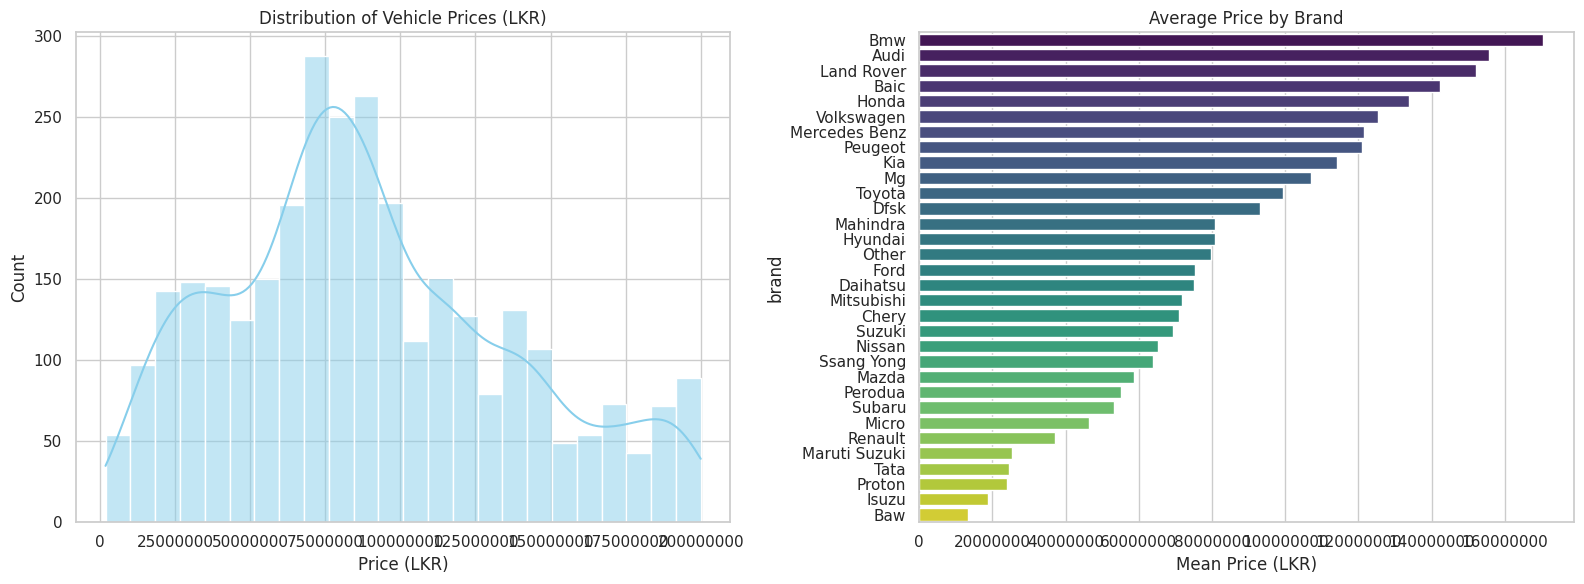

In [249]:
from IPython.display import FileLink
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Provide a manual clickable download link
print("Click the link below to download the processed data:")
display(FileLink('../data/processed/cleaned_cars.csv'))

# 2. Visualize Data
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Price Distribution
sns.histplot(df['price_lkr'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Vehicle Prices (LKR)')
axes[0].set_xlabel('Price (LKR)')
axes[0].ticklabel_format(style='plain', axis='x')

# Brand-wise Average Price
brand_prices = df.groupby('brand')['price_lkr'].mean().sort_values(ascending=False)
sns.barplot(x=brand_prices.values, y=brand_prices.index, ax=axes[1], palette='viridis', hue=brand_prices.index, legend=False)
axes[1].set_title('Average Price by Brand')
axes[1].set_xlabel('Mean Price (LKR)')
axes[1].ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Price vs Year to inspect remaining high-value outliers
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='year', y='price_lkr', alpha=0.5, hue='brand', palette='tab20', legend=False)
plt.title('Vehicle Price vs. Year (Post-Adjustment)')
plt.xlabel('Year of Manufacture')
plt.ylabel('Price (LKR)')
plt.yscale('log') # Log scale helps see the distribution across wide price ranges
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

print(f"Current Price Range: {df['price_lkr'].min():,} to {df['price_lkr'].max():,} LKR")

In [ ]:
from google.colab import files

# Alternative download method if FileLink fails
try:
    print("Attempting to trigger download for: " + PROCESSED_PATH)
    files.download(PROCESSED_PATH)
except Exception as e:
    print(f"Manual download failed: {e}")
    print("You can also download it manually by clicking the 'Folder' icon on the left sidebar, navigating to data/processed, right-clicking cleaned_cars.csv, and selecting 'Download'.")

# PART II: Predictive Modeling, Architecture Optimization, and Evaluation Pipeline

## II.0. Import data from previus stage

In [ ]:
# Environment Detection & Directory Ingestion Logic
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🚀 Environment: Google Colab detected.")
    from google.colab import files

    # Use global variables from Section 0
    os.makedirs(COLAB_INPUT_DIR, exist_ok=True)
    os.makedirs(COLAB_MODEL_DIR, exist_ok=True)

    # Check if processed file exists from previous script execution
    if not os.path.exists(PROCESSED_PATH):
        print("📥 Please upload your 'cleaned_cars.csv' file generated from the preprocessing notebook:")
        uploaded = files.upload()
        for filename in uploaded.keys():
            os.rename(filename, PROCESSED_PATH)

    model_output_path = os.path.join(COLAB_MODEL_DIR, 'vehicle_pricing_pipeline.pkl')
else:
    print("💻 Environment: Local Workspace detected.")
    # Use global variables from Section 0
    os.makedirs(LOCAL_MODEL_DIR, exist_ok=True)
    model_output_path = os.path.join(LOCAL_MODEL_DIR, 'vehicle_pricing_pipeline.pkl')

# Display data summary if available
if os.path.exists(PROCESSED_PATH):
    df_loaded = pd.read_csv(PROCESSED_PATH)
    print(f"✅ Data loaded successfully from {PROCESSED_PATH}")
    print(f"📊 Summary Statistics:")
    print(f"   - Total Records: {len(df_loaded)}")
    print(f"   - Features: {list(df_loaded.columns)}")
else:
    print(f"⚠️ Data file not found at {PROCESSED_PATH}. Please ensure it is generated or uploaded.")

## II.1. Model Matrix Separation and Target Domain Justification
Transitioning from the data pipeline layer to the model engineering layer requires isolating our independent feature vectors ($X$) from the dependent validation arrays ($y$).

**Justification for Log-Target Encoding:**
Automotive price assets naturally manifest a severe positive skewness (a heavy right-hand tail composed of anomalous premium luxury variants). Standard optimization objectives like Mean Squared Error ($MSE$) focus heavily on minimizing errors for these larger absolute magnitudes, causing the resulting prediction weights to favor high-end outliers.

By defining $y = \log_{e}(\text{price\_lkr} + 1)$, we stabilize the target distribution variance. This minimizes heteroscedasticity and allows tree node optimization algorithms to evaluate splits uniformly across both entry-level and premium automotive strata.

In [250]:
# Isolate the core feature spaces from the active working dataframe
X = df_loaded.drop(columns=['price_lkr', 'log_price'])
y = df_loaded['log_price']

# Map exact physical column categories to matching pipeline execution transformations
num_features = ['year', 'vehicle_age', 'mileage_km', 'log_mileage', 'engine_cc']
cat_features = ['source_site', 'brand', 'model', 'transmission', 'fuel_type', 'location']

print(f"Matrix layout generated successfully:")
print(f" - Independent Features: {X.shape[0]} rows across {X.shape[1]} descriptors.")
print(f" - Continuous predictors: {num_features}")
print(f" - Categorical predictors: {cat_features}")

Matrix layout generated successfully:
 - Independent Features: 3144 rows across 11 descriptors.
 - Continuous predictors: ['year', 'vehicle_age', 'mileage_km', 'log_mileage', 'engine_cc']
 - Categorical predictors: ['source_site', 'brand', 'model', 'transmission', 'fuel_type', 'location']


## II.2. End-to-End Pipeline Architecture and Feature Encoding
To enforce structural production standards and isolate cross-validation loops from data leakage, preprocessing layers are wrapped natively within a `scikit-learn` `Pipeline` and `ColumnTransformer` layout.

**Justification of Components:**
* **SimpleImputer (Defensive Engineering):** While stratified categorical medians were applied during data cleaning, adding an internal fallback imputer preserves application reliability. If the live Streamlit app processes an incomplete runtime block, it will impute the value safely rather than crashing.
* **StandardScaler:** Transforms continuous numerical values to zero mean and unit variance ($z = \frac{x - \mu}{\sigma}$), ensuring balanced convergence speeds for linear algorithms.
* **OneHotEncoder(handle_unknown='ignore'):** Text classes are converted into unique sparse binary indices. Crucially, explicitly setting `handle_unknown='ignore'` acts as a runtime safety mechanism. If a user enters an unrepresented location or brand in the deployed Streamlit environment, the transformer silently creates an all-zero vector for the unmapped column rather than crashing the interface.

In [251]:
# ## 11. ColumnTransformer and Encoding Pipeline Design
# We build an automated ColumnTransformer execution layer with integrated imputation.

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Numeric pipeline: Impute missing with median then scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: Impute missing with 'Unknown' then encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Build mapping schema
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ])

print("✅ Preprocessing pipeline with Imputers compiled.")

✅ Preprocessing pipeline with Imputers compiled.


In [251]:
# ## 12. Train-Test Partitioning
# We assign 20% of the active records to a testing validation split to assess out-of-sample generation accurately.

from sklearn.model_selection import train_test_split

# Apply a static seed index to enforce execution repeatability across environments
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Split distribution completed:")
print(f" - Learning Matrix: {X_train.shape[0]} training configurations.")
print(f" - Test Partition: {X_test.shape[0]} validation checks.")

## II.3. Baseline Framework Benchmarking & Metric Mapping
We implement an empirical model selection framework by benchmarking Multiple Linear Regression (Baseline) against non-linear architectures: Random Forest Regressor and XGBoost Regressor.

**Justification of Evaluation Methodology:**
Because continuous metrics are trained on the artificial log scale ($\ln(x+1)$), viewing raw evaluation margins in log units lacks operational business clarity. To evaluate the models effectively against real-world price dynamics, predictions are mapped back to the original Sri Lankan Rupee currency scale using an exponential transformation:

$$\text{Price}_{\text{LKR}} = e^{\text{log\_price}} - 1$$

We evaluate performance using two distinct metric axes:
1. **$R^2$ Score (Scale-Invariant):** Measures the global variance percentage captured by the models.
2. **Mean Absolute Error ($MAE$ in LKR):** Provides a clear financial error metric representing the average absolute cost deviation expected per vehicle valuation.

In [252]:
# ## 13. Baseline Framework Benchmarking
# We test Multiple Linear Regression as a standard baseline against advanced ensemble techniques (Random Forest and XGBoost).
#
# Justification: To provide actionable evaluation metrics for our final report, we scale the log predictions back to the original Sri Lankan Rupee currency space using np.expm1.

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Establish candidate architectures
models = {
    "Linear Regression (Baseline)": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost Regressor": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
}

results_summary = []

for name, model in models.items():
    # Encapsulate preprocessor and regressor components into a unified pipeline block
    # This now includes the SimpleImputer added in Section 11
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    pipeline.fit(X_train, y_train)

    # Predict validation parameters on log scale
    log_preds = pipeline.predict(X_test)

    # Reconstruct original scale variations
    true_lkr = np.expm1(y_test)
    pred_lkr = np.expm1(log_preds)

    # Calculate statistical performance boundaries
    r2 = r2_score(y_test, log_preds)
    mae_lkr = mean_absolute_error(true_lkr, pred_lkr)
    rmse_lkr = np.sqrt(mean_squared_error(true_lkr, pred_lkr))

    results_summary.append({
        "Model Architecture": name,
        "R2 Score": round(r2, 4),
        "MAE (LKR)": round(mae_lkr, 2),
        "RMSE (LKR)": round(rmse_lkr, 2)
    })

# Format structural metric data frames
df_results = pd.DataFrame(results_summary)
print("📊 Comparative Analysis Results Matrix:")
display(df_results)

📊 Comparative Analysis Results Matrix:


,Model Architecture,R2 Score,MAE (LKR),RMSE (LKR)
0,Linear Regression (Baseline),0.8365,11965867.16,21703797.84
1,Random Forest Regressor,0.8973,8497267.09,13928318.42
2,XGBoost Regressor,0.8995,9360348.72,14011583.79


## II.4. Debugging and Hyperparameter Optimization via 5-Fold Cross-Validation
Ensemble tree architectures (such as gradient-boosted systems) naturally carry an engineering risk of structural overfitting. If left unconstrained, trees will split nodes continuously until they map perfectly to individual training instances, resulting in low validation accuracy on unseen data.

**Justification of Optimization Parameters:**
We target our strongest candidate architecture (XGBoost) and run a 5-Fold Cross-Validation loop to identify the optimal configuration balance. We apply regularization boundaries to prevent overfitting:
* `max_depth` $[4, 6, 8]$ restricts the vertical complexity and high-order interaction capacity of individual tree learners.
* `learning_rate` $[0.05, 0.1, 0.2]$ (shrinkage rate) controls the optimization step sizes taken along the gradient surface, preventing the loss optimization function from overshooting global minima.

In [253]:
# ## 14. Debugging and Hyperparameter Optimization
# Deep ensemble steps can overfit localized variances when depth bounds are unrestricted.
# Justification: We target our strongest architecture (XGBoost) and configure a 5-Fold Cross-Validation search loop.

from sklearn.model_selection import RandomizedSearchCV, KFold

# Configure baseline architecture wrapper
base_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(random_state=42, n_jobs=-1))
])

# Define regularizing cross-validation hyperparameter distribution grids
param_distributions = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [4, 6, 8],
    'regressor__learning_rate': [0.05, 0.1, 0.2]
}

print("⏳ Executing 5-Fold Cross-Validation Optimization loops...")
search = RandomizedSearchCV(
    base_pipeline,
    param_distributions=param_distributions,
    n_iter=8,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)
print(f"\n🏆 Optimal parameters discovered:\n{search.best_params_}")
best_pipeline = search.best_estimator_

⏳ Executing 5-Fold Cross-Validation Optimization loops...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

🏆 Optimal parameters discovered:
{'regressor__n_estimators': 100, 'regressor__max_depth': 6, 'regressor__learning_rate': 0.2}


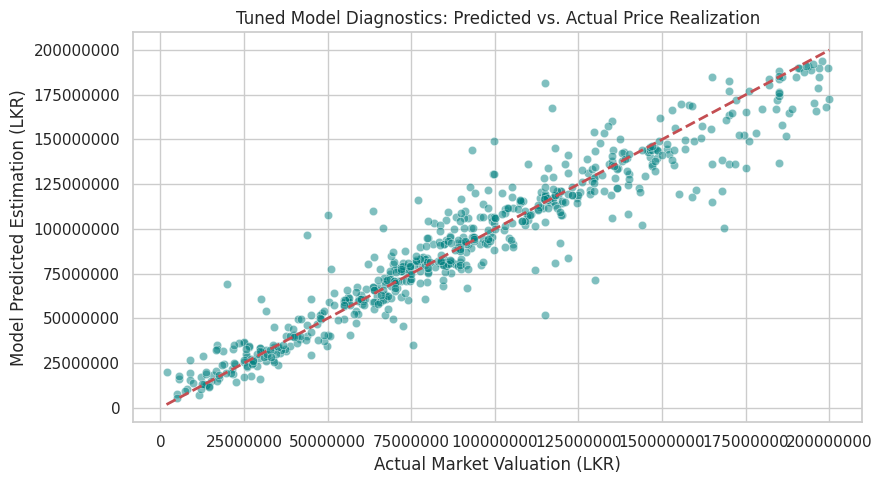

📈 Plot generation complete. Diagnostic file saved directly to: prediction_error_plot.png


In [254]:
# ## 15. Comprehensive Validation Analysis
# We generate visual diagnostic charts from the optimized pipeline models to export for our technical report.

import matplotlib.pyplot as plt
import seaborn as sns

# Generate finalized validation predictions
final_log_preds = best_pipeline.predict(X_test)
final_true_lkr = np.expm1(y_test)
final_pred_lkr = np.expm1(final_log_preds)

# Export validation scatter diagnostics
plt.figure(figsize=(9, 5))
sns.scatterplot(x=final_true_lkr, y=final_pred_lkr, alpha=0.5, color='teal')
plt.plot([final_true_lkr.min(), final_true_lkr.max()], [final_true_lkr.min(), final_true_lkr.max()], 'r--', lw=2)
plt.title('Tuned Model Diagnostics: Predicted vs. Actual Price Realization', fontsize=12)
plt.xlabel('Actual Market Valuation (LKR)')
plt.ylabel('Model Predicted Estimation (LKR)')
plt.ticklabel_format(style='plain', axis='both')
plt.tight_layout()

# Route export destinations dynamically to clean assets space
plot_out = 'prediction_error_plot.png' if IN_COLAB else '../assets/prediction_error_plot.png'
plt.savefig(plot_out, dpi=300)
plt.show()

print(f"📈 Plot generation complete. Diagnostic file saved directly to: {plot_out}")

## II.5. Unified Pipeline Serialization and Deployment Readiness
A core requirement of our system design is ensuring that the preprocessing logic matches perfectly across both the training environment and the production app.

**Justification of Approach:**
Instead of exporting only the raw model weights, we serialize the entire composite `Pipeline` object (containing the `ColumnTransformer`, `SimpleImputer`, `OneHotEncoder`, and tuned `XGBoost` parameters) into a unified binary format (`.pkl`).

This ensures that our Streamlit application does not require duplicated data-cleaning scripts. The live web server can ingest raw user text vectors, run `.predict()` directly on the object, and return accurate LKR pricing assessments seamlessly.

In [255]:
# ## 16. Unified Pipeline Serialization
# We save the finalized `best_pipeline` object. Because the resulting object embeds the fitted encoders and scalers directly within its structure, the live web interface can ingest raw string input matrices seamlessly.

import joblib
import os

# Isolate system output paths using environment detection
final_model_out = 'vehicle_pricing_pipeline.pkl' if IN_COLAB else '../models/vehicle_pricing_pipeline.pkl'

# Ensure directory exists for local environments
if not IN_COLAB:
    os.makedirs(os.path.dirname(final_model_out), exist_ok=True)

# Serialize pipeline object assets securely
joblib.dump(best_pipeline, final_model_out)
print(f"🎉 Success! Production artifact generated at: {final_model_out}")

if IN_COLAB:
    from google.colab import files
    print("✨ Downloading your production-ready pipeline pkl asset down to local storage...")
    files.download(final_model_out)

🎉 Success! Production artifact generated at: vehicle_pricing_pipeline.pkl
✨ Downloading your production-ready pipeline pkl asset down to local storage...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>